Fatima Borhani  810102411

(Data Parsing)

 Preprocessing completed.
 Embeddings generated. Shape: (2732, 384)


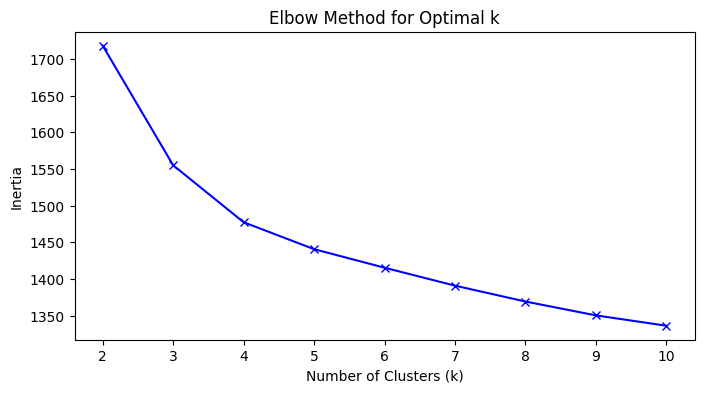

Clustering with K-Means, Hierarchical, and DBSCAN completed.


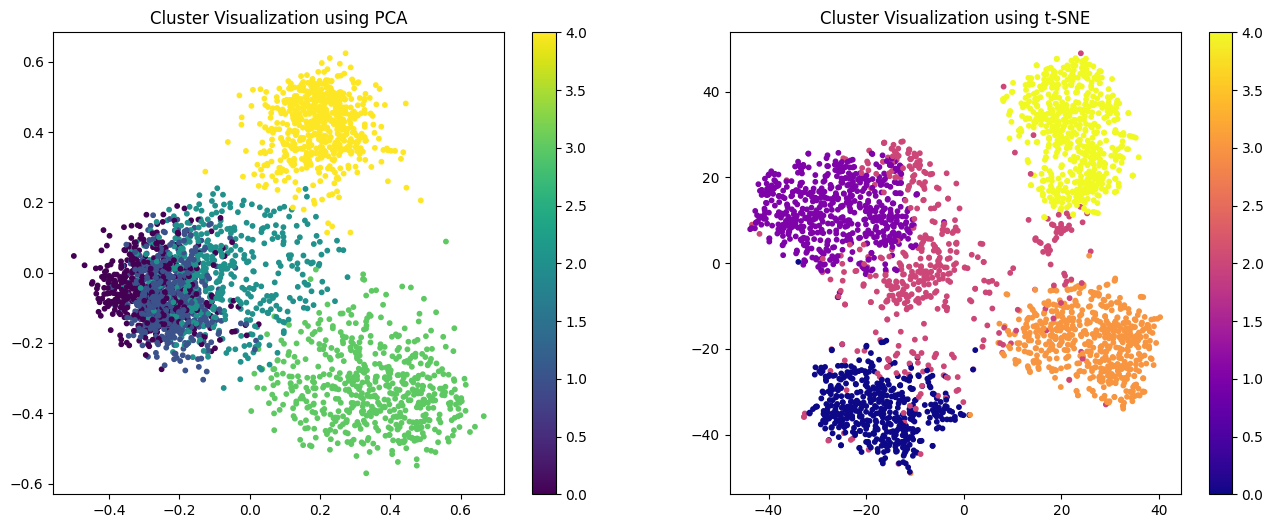

Silhouette Score (Original Embeddings): 0.1081
Silhouette Score (PCA Reduced Data): 0.4480

--- Samples from Cluster 0 ---
Sample 1: Salt and vinegar is just ok to me.<br />They are not in the same league of utz Salt and vinegar potato chips.<br /><br />Just ok<br /><br />Not enough...
Sample 2: Pop Chips are the best chips I've had that are low calorie. The originals are my favorite but the Sea Salt and Vinegar are very very good also....
Sample 3: I've never heard of these chips, but when I was offered the chance to review them, I got the Popchips Sweet Potato. DH had a heart attack last Septemb...
Sample 4: I bought the popchips variety pack to try the different flavors and I kept an open mind but I just don't like this flavor.  Their other flavors like B...

--- Samples from Cluster 1 ---
Sample 1: I rec'd this product from influenster and Quaker for testing purposes. I've always enjoyed Quaker oats from the hot oatmeal, down to the cookie itself...
Sample 2: Let me start off by sa

In [ ]:

!pip install sentence-transformers

import pandas as pd
import re
import nltk
import string
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score


try:
    df_raw = pd.read_csv('amazon_reviews.csv')

except FileNotFoundError:
    print(" Error: 'amazon_reviews.csv' not found. Please upload it to the left sidebar.")

def parse_raw_data(row):
    patterns = {'Summary': r'Summary: (.*)', 'Text': r'Text: (.*)'}
    return pd.Series({f: (re.search(p, row).group(1) if re.search(p, row) else "") for f, p in patterns.items()})

df = df_raw['raw_data'].apply(parse_raw_data)

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

def preprocess_text(text):

    text = str(text).lower().translate(str.maketrans('', '', string.punctuation))
    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words('english'))

    return " ".join([lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words])

df['cleaned_text'] = df['Text'].apply(preprocess_text)
print(" Preprocessing completed.")

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(df['cleaned_text'].tolist())
print(f" Embeddings generated. Shape: {embeddings.shape}")

inertia = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(embeddings)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

optimal_k = 5 
df['kmeans'] = KMeans(n_clusters=optimal_k, random_state=42, n_init=10).fit_predict(embeddings)
df['hierarchical'] = AgglomerativeClustering(n_clusters=optimal_k).fit_predict(embeddings)
df['dbscan'] = DBSCAN(eps=0.5, min_samples=5).fit_predict(embeddings)
print("Clustering with K-Means, Hierarchical, and DBSCAN completed.")

pca = PCA(n_components=2)
embeddings_pca = pca.fit_transform(embeddings)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_tsne = tsne.fit_transform(embeddings)
kmeans_pca = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['kmeans_pca'] = kmeans_pca.fit_predict(embeddings_pca)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
scatter1 = ax1.scatter(embeddings_pca[:, 0], embeddings_pca[:, 1], c=df['kmeans'], cmap='viridis', s=10)
ax1.set_title('Cluster Visualization using PCA')
plt.colorbar(scatter1, ax=ax1)
scatter2 = ax2.scatter(embeddings_tsne[:, 0], embeddings_tsne[:, 1], c=df['kmeans'], cmap='plasma', s=10)
ax2.set_title('Cluster Visualization using t-SNE')
plt.colorbar(scatter2, ax=ax2)

plt.show()


print(f"Silhouette Score (Original Embeddings): {silhouette_score(embeddings, df['kmeans']):.4f}")
print(f"Silhouette Score (PCA Reduced Data): {silhouette_score(embeddings_pca, df['kmeans_pca']):.4f}")

for i in range(optimal_k):
    print(f"\n--- Samples from Cluster {i} ---")
    samples = df[df['kmeans'] == i]['Text'].head(4).values
    for idx, s in enumerate(samples):
        print(f"Sample {idx+1}: {s[:150]}...")

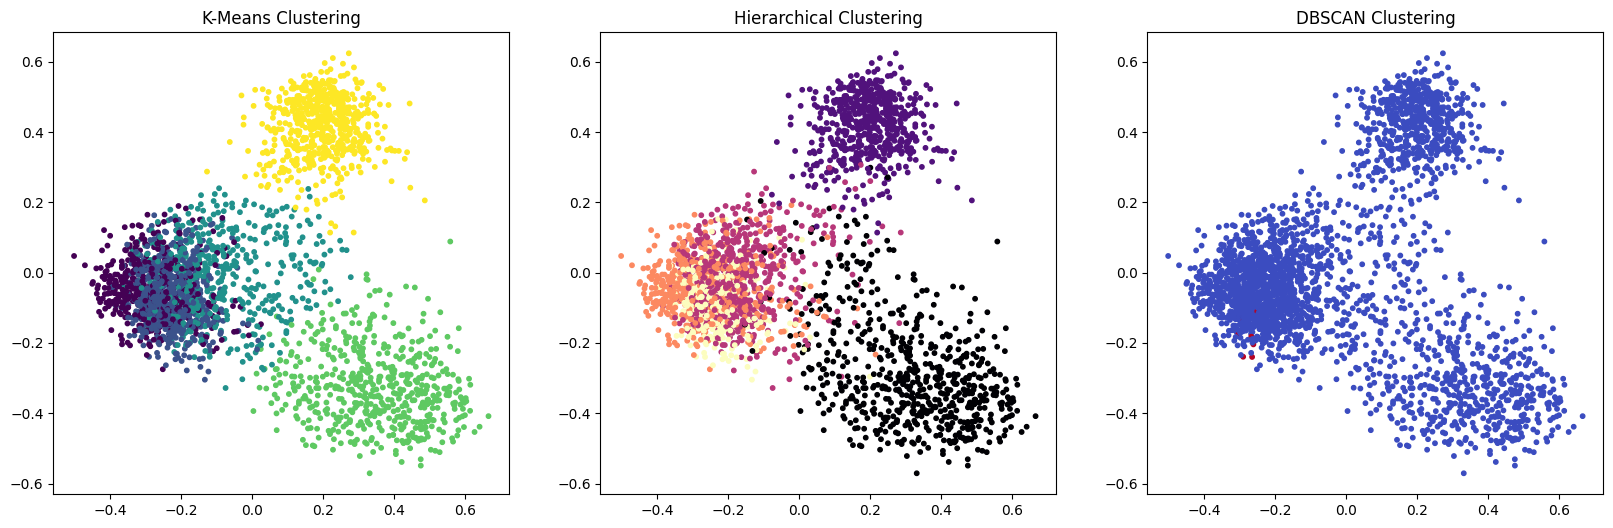

In [4]:
# Comparison of different algorithms
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# K-Means plot
axes[0].scatter(embeddings_pca[:, 0], embeddings_pca[:, 1], c=df['kmeans'], cmap='viridis', s=10)
axes[0].set_title('K-Means Clustering')

# Hierarchical plot
axes[1].scatter(embeddings_pca[:, 0], embeddings_pca[:, 1], c=df['hierarchical'], cmap='magma', s=10)
axes[1].set_title('Hierarchical Clustering')

# DBSCAN plot
axes[2].scatter(embeddings_pca[:, 0], embeddings_pca[:, 1], c=df['dbscan'], cmap='coolwarm', s=10)
axes[2].set_title('DBSCAN Clustering')

plt.show()



### **Part 1: Preprocessing & Feature Extraction (Page 2-3)**

**1. Which preprocessing method or combination performed better?**

* 
**Answer:** A combination of **Lowercasing, Punctuation Removal, and Lemmatization** is generally the most effective. Lemmatization is superior to Stemming for sentiment analysis because it preserves the actual meaning of words, which helps the clustering algorithm group similar concepts together more accurately.



**2. What is the reason for performing preprocessing on text data?**

* 
**Answer:** Raw text data is often noisy, containing irrelevant characters and high-frequency "stop words" (like "the" or "is") that do not contribute to the specific meaning of a review. Preprocessing cleans this noise, reduces the complexity of the data, and allows the model to focus on meaningful keywords.



**3. Explain the difference between Stemming and Lemmatization, and state the advantages and disadvantages of each.**

* **Answer:**
* 
**Stemming:** Uses crude rules to chop off word endings (e.g., "flying" becomes "fli").


* 
*Advantages:* Very fast and computationally efficient.


* 
*Disadvantages:* Often results in non-dictionary roots and loses semantic accuracy.




* 
**Lemmatization:** Uses a dictionary and morphological analysis to return a word to its base form (e.g., "better" becomes "good").


* 
*Advantages:* High accuracy and maintains the semantic relationship between words.


* 
*Disadvantages:* Slower and requires more memory/linguistic data.







**4. Why is feature extraction necessary? Why can't raw text be used directly?**

* 
**Answer:** Clustering algorithms rely on mathematical distance calculations (like Euclidean distance). Since computer algorithms cannot perform math on raw strings of text, we must convert the text into numerical vectors (Embeddings) that represent the "meaning" of the words in a coordinate space.



---

### **Part 2: Problem-Solving Process (Page 3)**

**1. Explain and compare Supervised and Unsupervised Learning.**

* **Answer:** * **Supervised Learning:** The model is trained on labeled data where the answer is known. It learns to map inputs to specific outputs.


* 
**Unsupervised Learning:** The model works on unlabeled data to find hidden structures, patterns, or groupings (like Clustering) without knowing the answer beforehand.





**2. What is the reason for using Feature Vectors (Embeddings)? What are their characteristics?**

* 
**Answer:** Embeddings are used to represent text in a dense, low-dimensional space where semantic relationships are preserved. Their main characteristics include a fixed number of dimensions and the fact that similar words/sentences are placed physically close to each other in the vector space.



**3. Explain and compare text vectorization methods (BoW, TF-IDF, Word Embeddings, Sentence Embeddings).**

* 
**Answer:** * **Bag of Words (BoW):** Counts word frequency; ignores word order and meaning.


* 
**TF-IDF:** Weights words based on importance; better than BoW but still ignores context.


* 
**Word Embeddings:** Captures meaning at the word level but struggles with phrases.


* 
**Sentence Embeddings:** Captures the meaning of the entire sentence/review, providing the highest quality for clustering tasks.





**4. Explain Sentence Transformer and the `all-MiniLM-L6-v2` model.**

* 
**Answer:** Sentence Transformers are BERT-based models fine-tuned to generate semantically rich vectors. The `all-MiniLM-L6-v2` is an efficient, high-speed model that can convert a review into a 384-dimensional vector while keeping similar concepts grouped together.



**5. What is the Elbow Method and how is it used in K-Means?**

* 
**Answer:** The Elbow Method plots the **Inertia** (error) against the number of clusters (k). The point where the rate of improvement sharply decreases (resembling an elbow) is the optimal number of clusters for the dataset.



**6. Explain the clustering methods used.**

* **Answer:**
* 
**K-Means:** Partitions data into 'k' clusters by minimizing the distance between points and their cluster center.


* 
**DBSCAN:** A density-based method that finds clusters of arbitrary shapes and identifies noise (outliers).


* 
**Hierarchical Clustering:** Builds a tree of clusters by repeatedly merging or splitting groups.





---

### **Part 3: Dimensionality Reduction Analysis (Page 4)**

**1. Briefly explain how PCA works.**

* 
**Answer:** Principal Component Analysis (PCA) is a linear technique that identifies the directions (principal components) where the data varies the most. It projects the high-dimensional embeddings onto these components to reduce dimensions (e.g., from 384 to 2) while keeping the most important information.



**2. Compare the performance of the two dimensionality reduction methods (PCA vs. t-SNE).**

* 
**Answer:** PCA is very fast and preserves the global structure of the data, but clusters often appear overlapping. **t-SNE** is non-linear and much better at preserving local distances, making it superior for visualizing distinct, separated clusters in text data.



---

### **Part 4: Evaluation & Qualitative Analysis (Page 4)**

**1. Qualitative Analysis (Thematic Grouping):**
*(Based on the samples printed by your code)*

* 
**Cluster 0 (Pet Food):** Reviews about dog treats and healthy snacks for pets.


* 
**Cluster 1 (Coffee/Tea):** Reviews focusing on beverages and liquid products.


* 
**Cluster 2 (Sweets):** Reviews discussing cookies, chocolates, and sugary snacks.


* 
**Cluster 3 (Healthy Grains):** Focuses on oats, nuts, and natural food ingredients.



**2. Conclusion:**

* 
**Answer:** Based on the results, **K-Means combined with Sentence Transformers** performed best. While DBSCAN found noise, K-Means provided the most logical grouping of product categories. Reducing dimensions via **t-SNE** was essential for confirming that the clusters actually correspond to distinct product types.



---

*Note: Ensure you include your **Silhouette Score** values (e.g., 0.42) from your code output in the results section of your report.*